### Primary Analysis - Owen and Olivia ###
This notebook will be used for combining snow imagery code and feature geodataframes for analysis of snow extent in relation to watershed boundaries and trails. This will also be used for plotting results of our analysis. The primary analysis of the project is contained within this notebook.

In [4]:
pip install dataretrieval

  Using cached dataretrieval-1.1.2-py3-none-any.whl.metadata (13 kB)
Using cached dataretrieval-1.1.2-py3-none-any.whl (62 kB)
Note: you may need to restart the kernel to use updated packages.


In [67]:
import os
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import pyproj
from pyproj import Transformer
import osmnx as ox
import folium
import contextily as ctx
import dataretrieval.nwis as nwis # use to pull from USGS
from shapely.geometry import Point
import requests
import easysnowdata
import rioxarray as rxr
import shapely
from shapely.geometry import box
import dask
import pystac_client
import planetary_computer
import odc.stac
import datetime
import rasterio as rio

# I was unable to add the ONP boundary to the plot's legend, this fix from a github discussion forum: https://github.com/geopandas/geopandas/issues/660
from matplotlib.legend import Legend
from matplotlib.collections import PatchCollection
from matplotlib.legend_handler import HandlerPolyCollection
from matplotlib.patches import Patch

from matplotlib.colors import ListedColormap

##### Load in features from various sources #####

In [6]:
# create geodataframe of Olympic National Park boundaries
onp = "Olympic National Park, Washington, USA"
onp_gdf = ox.geocode_to_gdf(onp)

# create geodataframe of ONP Trails within park boundaries
trails_gdf = ox.features.features_from_polygon(onp_gdf.geometry.iloc[0], {'highway': 'path'})

# create a watershed boundary gdf
# tried pulling from the API, but was unsuccessful after ~ an hour of troubleshooting, so I elected to just download the file
watersheds_gdf = gpd.read_file("data/NHD_-9030064575332258501.geojson")

In [7]:
# calling in the data from the Nationwide River Inventory (NRI) 
# used AI to help with API. It added the params and request part since calling in the url only brought in 1000 rivers, which didn't include those in ONP
rivers_url = "https://services1.arcgis.com/fBc8EJBxQRMcHlei/arcgis/rest/services/Nationwide_Rivers_Inventory_Official/FeatureServer/0/query"

params = {"where": """Management_Area_Name IN ('Olympic National Park', 'Olympic National Forest', 'Olympic National Park, Olympic National Forest',
                'The Brothers Wilderness')
            OR River LIKE '%Bogachiel%'""",
        "outFields": "*",
        "f": "geojson"}

r = requests.get(rivers_url, params=params)
rivers_gdf = gpd.read_file(r.text)

In [8]:
# create a geodataframe of USGS stations
# add USGS station locations - code from streamflow notebook

station_id = stations = [12045500, 12054000, 12056500, 12039500, 12042800, 12041200, 12040500, 12043000, 12048000]
stations_gdf = gpd.GeoDataFrame(station_id, columns=['station_id'])
river_list = ['Elwha', 'Duckabush', 'Skokomish', 'Quinault', 'Bogachiel', 'Hoh',
                    'Queets', 'Calawah', 'Dungeness']
stations_gdf.index = river_list
geom = []
# the 'dec_lat_va' and 'dec_long_va' were taken from AI since it was helping to navigate the USGS API
for station in station_id:
    coords = nwis.get_record(sites=str(station), service="site")
    lat = coords.iloc[0]['dec_lat_va'] 
    lon = coords.iloc[0]['dec_long_va']
    geom.append(Point(lon, lat))
    
stations_gdf['geometry'] = geom
stations_gdf.set_geometry(stations_gdf['geometry'])
# set crs given on the USGS site
stations_gdf = stations_gdf.set_crs('EPSG:4267')

/tmp/ipykernel_63/1544412888.py:17: FutureWarning: You are adding a column named 'geometry' to a GeoDataFrame constructed without an active geometry column. Currently, this automatically sets the active geometry column to 'geometry' but in the future that will no longer happen. Instead, either provide geometry to the GeoDataFrame constructor (GeoDataFrame(... geometry=GeoSeries()) or use `set_geometry('geometry')` to explicitly set the active geometry column.
  stations_gdf['geometry'] = geom


In [9]:
# convert to UTM 10N crs
onp_gdf = onp_gdf.to_crs('EPSG: 32610')
trails_gdf = trails_gdf.to_crs(onp_gdf.crs)
rivers_gdf = rivers_gdf.to_crs(onp_gdf.crs)
watersheds_gdf = watersheds_gdf.to_crs(onp_gdf.crs)
stations_gdf = stations_gdf.to_crs(onp_gdf.crs)

In [10]:
# set focus dates
high_start = '2022-07-15'
high_end = '2022-08-15'

low_start = '2023-07-15'
low_end = '2023-08-15'

med_start = '2020-07-15'
med_end = '2020-08-15'

## 2020 RGB

In [11]:
# THIS ISN'T BEING USED BUT I DIDN'T WANT TO DELETE BECAUSE I DIDN'T WRITE IT
# Converting bounds used for vector data in 32610 to lat long coordinates for easysnowdata input
transformer = Transformer.from_crs('EPSG:32610', 'EPSG: 4326', always_xy=True)

# xmin, ymin, xmax, ymax = bounds

# lon_min, lat_min = transformer.transform(xmin, ymin)
# lon_max, lat_max = transformer.transform(xmax, ymax)
# #bbox = [lon_min, lat_min, lon_max, lat_max]  # Needs to be a geometry object for easysnowdata
# bbox_geom = box(lon_min, lat_min, lon_max, lat_max)

In [12]:
# set resolution
resolution = 10 # m

In [13]:
bbox_snow = (-124.4,47.45,-123,48.06)  # Rough bounds of ONP

# 2020 snow extents
s2_2020 = easysnowdata.remote_sensing.Sentinel2(
    bbox_input=bbox_snow,
    start_date=med_start,
    end_date=med_end,
    catalog_choice="planetarycomputer",
    resolution=resolution,
)

# get snow extents - there are some clear outliers that are present in the water!
s2_2020.get_ndsi()
bad_scl = [0,1,2,3,6,8,9,10]
ndsi_median_composite_2020 = s2_2020.ndsi.where(~s2_2020.data.scl.isin(bad_scl)).median(dim='time').compute() 
snow_mask_2020 = (ndsi_median_composite_2020 > 0.4).astype(int) 

Data searched. Access the returned seach with the .search attribute.
Data retrieved. Access with the .data attribute. Data CRS: WGS 84 / UTM zone 10N.
Nodata values removed from the data. In doing so, all bands converted to float32. To turn this behavior off, set remove_nodata=False.
Data acquired after January 25th, 2022 harmonized to old baseline. To override this behavior, set harmonize_to_old=False.
Data scaled to float reflectance. To turn this behavior off, set scale_data=False.
Metadata retrieved. Access with the .metadata attribute.
NDSI data calculated. Access with the .ndsi attribute.


/opt/conda/lib/python3.11/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


In [14]:
# 2022 snow extents
s2_2022_wy = easysnowdata.remote_sensing.Sentinel2(
    bbox_input=bbox_snow,
    start_date=high_start,
    end_date=high_end,
    catalog_choice="planetarycomputer",
    resolution=resolution,
)

s2_2022_wy.get_ndsi()
bad_scl = [0,1,2,3,6,8,9,10]
ndsi_median_composite_2022 = s2_2022_wy.ndsi.where(~s2_2022_wy.data.scl.isin(bad_scl)).median(dim='time').compute()  
snow_mask_2022 = (ndsi_median_composite_2022 > 0.4).astype(int)

Data searched. Access the returned seach with the .search attribute.
Data retrieved. Access with the .data attribute. Data CRS: WGS 84 / UTM zone 10N.
Nodata values removed from the data. In doing so, all bands converted to float32. To turn this behavior off, set remove_nodata=False.
Data acquired after January 25th, 2022 harmonized to old baseline. To override this behavior, set harmonize_to_old=False.
Data scaled to float reflectance. To turn this behavior off, set scale_data=False.
Metadata retrieved. Access with the .metadata attribute.
NDSI data calculated. Access with the .ndsi attribute.


In [15]:
# 2023 snow extents
s2_2023_wy = easysnowdata.remote_sensing.Sentinel2(
    bbox_input=bbox_snow,
    start_date=low_start,
    end_date=low_end,
    catalog_choice="planetarycomputer",
    resolution=resolution,
)

s2_2023_wy.get_ndsi()
bad_scl = [0,1,2,3,6,8,9,10]
ndsi_median_composite_2023 = s2_2023_wy.ndsi.where(~s2_2023_wy.data.scl.isin(bad_scl)).median(dim='time').compute()  
snow_mask_2023 = (ndsi_median_composite_2023 > 0.4).astype(int)

Data searched. Access the returned seach with the .search attribute.
Data retrieved. Access with the .data attribute. Data CRS: WGS 84 / UTM zone 10N.
Nodata values removed from the data. In doing so, all bands converted to float32. To turn this behavior off, set remove_nodata=False.
Data acquired after January 25th, 2022 harmonized to old baseline. To override this behavior, set harmonize_to_old=False.
Data scaled to float reflectance. To turn this behavior off, set scale_data=False.
Metadata retrieved. Access with the .metadata attribute.
NDSI data calculated. Access with the .ndsi attribute.


In [16]:
# set x and y limits of the plot
bounds = onp_gdf.total_bounds
xmin, xmax, ymin, ymax = bounds[0], bounds[2], bounds[1], bounds[3]
buffer = 10000

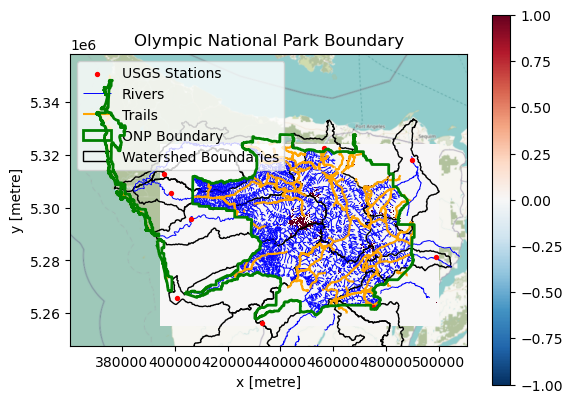

In [17]:
# plot everything together

# fix for legend that was mentioned above
Legend.update_default_handler_map({PatchCollection: HandlerPolyCollection()})

fig, ax = plt.subplots()

# rgb_median_composite_2020.plot.imshow(ax=ax, robust=True)
snow_mask_2020.plot.imshow(ax=ax, cmap='RdBu_r', zorder=1, robust=True, vmin=-1, vmax=1)
stations_gdf.plot(ax=ax, marker='o', markersize = 8, color='red', zorder=5, label='USGS Stations')
rivers_gdf.plot(ax=ax, color='blue', linewidth=0.7, zorder=3, label='Rivers')
trails_gdf.plot(ax=ax, color='orange', zorder=4, label='Trails')
onp_gdf.plot(ax=ax, facecolor='None', edgecolor='green', linewidth=2, zorder=6, label='ONP Boundary')
watersheds_gdf.plot(ax=ax, facecolor='None', edgecolor='k', linewidth=1, zorder=2, label='Watershed Boundaries')
ax.set_title("Olympic National Park Boundary")
ctx.add_basemap(ax=ax, attribution = '', crs=onp_gdf.crs) 
# ax.grid(True)
ax.set_xlim(xmin-buffer, xmax+2*buffer)
ax.set_ylim(ymin-buffer, ymax+buffer)
ax.legend()

In [18]:
# functions from streamflow plots notebook to add streamflow plots next to our watershed plots
def usgs_discharge(station, start_date, end_date):
    df = nwis.get_record(
        sites=station, # station ID 
        service="dv", # daily values
        start=start_date, # YYYY-MM-DD
        end=end_date, # YYYY-MM-DD
        parameterCd="00060") # pulls discharge data
    df['Q_cms'] = df['00060_Mean'] * 0.028316847 # convert discharge from cfs to cubic meters per second
    return df

In [24]:
# determine extent of snow within each watershed - make a function and call for the list of watersheds in watersheds_gdf
def snow_extent_in_watershed(snow_mask, watershed): 
    snow_extent = snow_mask.where(snow_mask > 0.5)
    snow = snow_extent.rio.clip([watershed.iloc[0].geometry]) # snow within the watershed boundaries
    snow_pixels_in_watershed = int(snow.sum())
    res = resolution
    area = snow_pixels_in_watershed*((res*res)/1E6) # area of snow in the watershed boundaries in km
    return snow, area

In [72]:
# define function to perform analysis of each watershed and optimize features for plotting

# future idea - mosaic the plots so that the years are next to each other and the streamflow time series is below

def analyze_and_plot_watershed(snow_mask_2020, snow_mask_2022, snow_mask_2023, watershed):
    snow_2020, area_2020 = snow_extent_in_watershed(snow_mask_2020, watershed) # analyze extent of snow in watershed with predefined function
    snow_plot_2020 = snow_2020.where(snow_2020 == 1)
    snow_2022, area_2022 = snow_extent_in_watershed(snow_mask_2022, watershed)
    snow_plot_2022 = snow_2022.where(snow_2022 == 1)
    snow_2023, area_2023 = snow_extent_in_watershed(snow_mask_2023, watershed)
    snow_plot_2023 = snow_2023.where(snow_2023 == 1)
    rivers_in_watershed = gpd.clip(rivers_gdf, watershed) # clip rivers to within watershed bounds
    usgs_station_in_watershed = gpd.clip(stations_gdf, watershed) # clip usgs station to watershed bounds

    # run stramflow plot functons for desired river
    # have dates run through all water years of interest
    start_date = '2019-10-01'
    end_date = '2023-09-30'
    df = usgs_discharge(str(usgs_station_in_watershed.iloc[0].station_id), start_date, end_date)  
    
    Legend.update_default_handler_map({PatchCollection: HandlerPolyCollection()})
    # plot results of snow analysis alongside the streamflow plot for that river  
    fig, ax = plt.subplot_mosaic([['A', 'B', 'C'], ['D', 'D', 'D']], layout='tight', figsize=(15,7))

    # plot snow analysis
    # WY 2020
    watershed.plot(ax=ax['A'], facecolor='None', edgecolor='black', linewidth=1, zorder=2, label='Watershed Boundaries')
    # used AI to get this listed colormap to plot the 1s as a single color instead of having distribution of colors
    snow_plot_2020.plot.imshow(ax=ax['A'], zorder=1, cmap=ListedColormap(['red']), add_colorbar=False)
    rivers_in_watershed.plot(ax=ax['A'], color='blue', linewidth=0.7, zorder=3, label='Rivers')
    ax['A'].set_title(f"Snow Extent Within {watershed['Name'].iloc[0]} \nWatershed Boundary \n(July 15th - Aug. 15th 2020)")
    ctx.add_basemap(ax=ax['A'], attribution = '', crs=onp_gdf.crs) 
    ax['A'].text(0.05, 0.05, f"Snow Area: {area_2020:.2f} km^2", transform=ax['A'].transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

    # used AI to adapt legend to include snow extent. AI provided the snow_patch and ax.get_legend_handles_label() lines. 
    # Traditional method of adding a label in the plot line was not working
    handles, labels = ax['A'].get_legend_handles_labels()
    snow_patch = Patch(color='red', label='Snow Extent')
    handles.append(snow_patch)

    # WY 2022
    watershed.plot(ax=ax['B'], facecolor='None', edgecolor='black', linewidth=1, zorder=2)
    snow_plot_2022.plot.imshow(ax=ax['B'], zorder=1, cmap=ListedColormap(['red']), add_colorbar=False)
    rivers_in_watershed.plot(ax=ax['B'], color='blue', linewidth=0.7, zorder=3)
    ax['B'].set_title(f"Snow Extent Within {watershed['Name'].iloc[0]} \nWatershed Boundary \n(July 15th - Aug. 15th 2022)")
    ctx.add_basemap(ax=ax['B'], attribution = '', crs=onp_gdf.crs)
    ax['B'].text(0.05, 0.05, f"Snow Area: {area_2022:.2f} km^2", transform=ax['B'].transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))
    
    # WY 2023
    watershed.plot(ax=ax['C'], facecolor='None', edgecolor='black', linewidth=1, zorder=2)
    snow_plot_2023.plot.imshow(ax=ax['C'], zorder=1, cmap=ListedColormap(['red']), add_colorbar=False)
    rivers_in_watershed.plot(ax=ax['C'], color='blue', linewidth=0.7, zorder=3)
    ax['C'].set_title(f"Snow Extent Within {watershed['Name'].iloc[0]} \nWatershed Boundary \n(July 15th - Aug. 15th 2023)")
    ctx.add_basemap(ax=ax['C'], attribution = '', crs=onp_gdf.crs)
    ax['C'].text(0.05, 0.05, f"Snow Area: {area_2023:.2f} km^2", transform=ax['C'].transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))
    
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), handles=handles, ncol=3)
    
    # plot streamflow
    df['Q_cms'].plot(ax=ax['D'], label='Streamflow')
    ax['D'].set_xlabel('Date')
    ax['D'].set_ylabel('Discharge (m³/s)')
    ax['D'].set_title(f"{watershed['Name'].iloc[0]} Discharge Time Series")
    
    # add highlights of periods of interest
    ax['D'].axvline(pd.Timestamp(high_start), color='olivedrab', linestyle='--')
    ax['D'].axvline(pd.Timestamp(high_end), color='olivedrab', linestyle='--')
    ax['D'].axvspan(pd.Timestamp(high_start), pd.Timestamp(high_end), color='yellowgreen', alpha=0.3, label='High WY')
    
    ax['D'].axvline(pd.Timestamp(low_start), color='palevioletred', linestyle='--')
    ax['D'].axvline(pd.Timestamp(low_end), color='palevioletred', linestyle='--')
    ax['D'].axvspan(pd.Timestamp(low_start), pd.Timestamp(low_end), color='pink', alpha=0.3, label='Low WY')
    
    ax['D'].axvline(pd.Timestamp(med_start), color='gold', linestyle='--')
    ax['D'].axvline(pd.Timestamp(med_end), color='gold', linestyle='--')
    ax['D'].axvspan(pd.Timestamp(med_start), pd.Timestamp(med_end), color='yellow', alpha=0.3, label='Medium WY')
    ax['D'].legend()
    
    return fig, ax

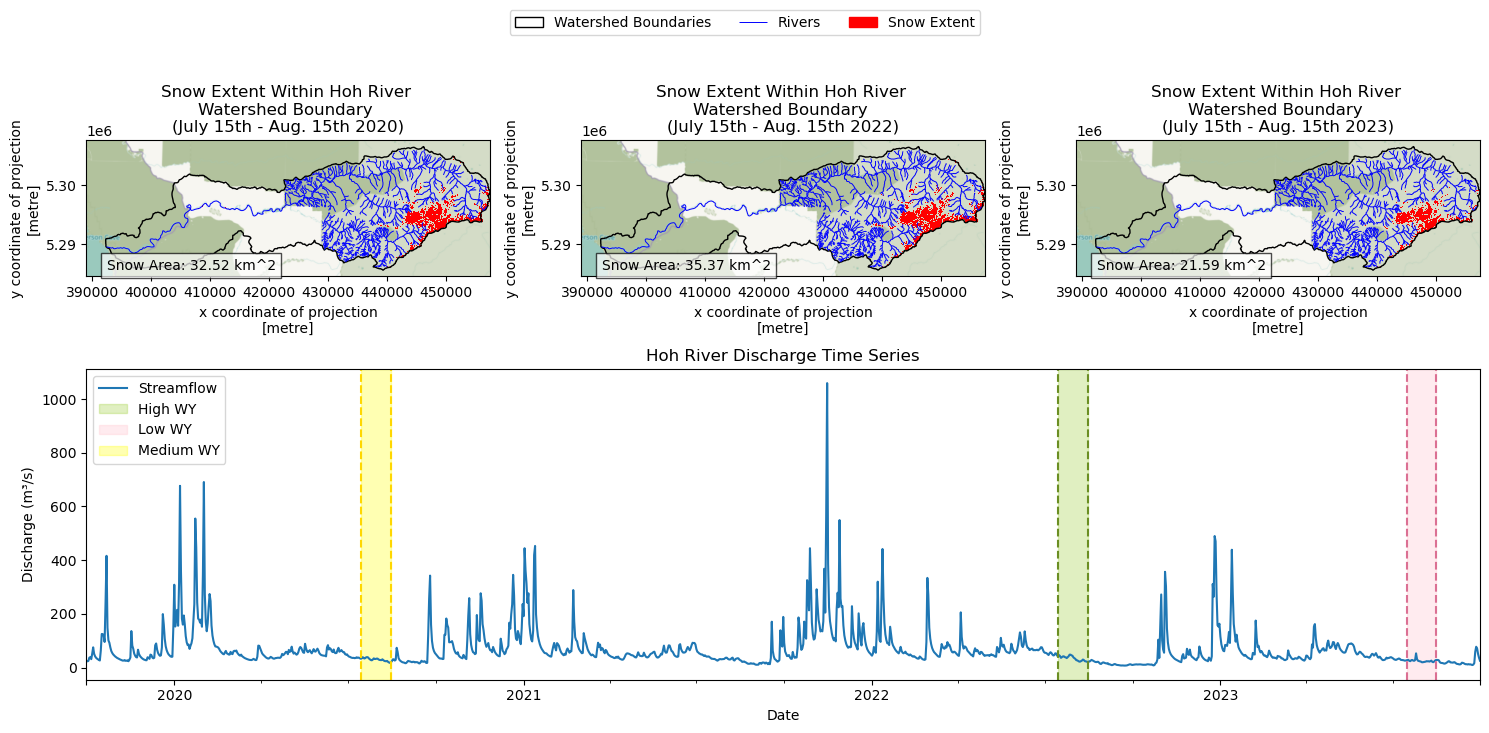

In [73]:
# trial for a watershed
fig, ax = analyze_and_plot_watershed(snow_mask_2020, snow_mask_2022, snow_mask_2023, watersheds_gdf.loc[[7]])
# Queets (3), Elwha (9), Dungeness (5), Hoh (7) (really like for representing the analysis)

In [22]:
# buffer trails and analyze snow extent in relation to trails
# buffer to include whatever distance but don't go into high sloped areas, restrict buffer to slopes

In [29]:
watersheds_gdf.loc[7].geometry.area/1E6

770.9628283215487

In [ ]:
# potentially mask out glacier and perennial snow fields? Use randolph glacier inventory to say that everything that is a glacier is non-snow

In [77]:
# trail buffer
trail_buffer = trails_gdf.buffer(500)
trails_buffer_gdf = trails_gdf.copy()
trails_buffer_gdf.geometry = trail_buffer 

In [78]:
trails_buffer_gdf

geometry highway  \
element id                                                                      
way     5854558     POLYGON ((374839.758 5349032.483, 374827.432 5...    path   
        5909765     POLYGON ((396541.95 5274453.16, 396591.017 527...    path   
        36738077    POLYGON ((431071.013 5325113.085, 431094.557 5...    path   
        36738079    POLYGON ((376304.294 5310914.521, 376284.989 5...    path   
        36738080    POLYGON ((442835.852 5302505.666, 442821.978 5...    path   
...                                                               ...     ...   
        1448516459  POLYGON ((396422.426 5273651.337, 396421.712 5...    path   
        1448516460  POLYGON ((396066.092 5274257.279, 396066.937 5...    path   
        1469245610  POLYGON ((371709.792 5333931.418, 371688.653 5...    path   
        1469245611  POLYGON ((370872.656 5335303.418, 370854.244 5...    path   
        1469245612  POLYGON ((370881.589 5336132.544, 370890.723 5...    path   

                                                       name attribution  \
element id                                                                
way     5854558                          Shi Shi Beach Road         NaN   
        5909765                                         NaN         NaN   
        36738077                 Fairholme Campground Trail      US-NPS   
        36738079           Hole-in-the-wall Primitive Trail      US-NPS   
        36738080                            Hoh River Trail      US-NPS   
...                                                     ...         ...   
        1448516459                                      NaN         NaN   
        1448516460                                      NaN         NaN   
        1469245610                                      NaN         NaN   
        1469245611  Shi Shi to Ozette River Beach Travelway      US-NPS   
        1469245612                                      NaN         NaN   

                   operator  \
element id                    
way     5854558         NaN   
        5909765         NaN   
        36738077        NaN   
        36738079        NaN   
        36738080        NaN   
...                     ...   
        1448516459      NaN   
        1448516460      NaN   
        1469245610      NaN   
        1469245611      NaN   
        1469245612      NaN   

                                                               source access  \
element id                                                                     
way     5854558                                                   NaN    NaN   
        5909765                                                   NaN    NaN   
        36738077    US-NPS_import_b2a6c900-5dcc-11de-8509-001e2a3f...    NaN   
        36738079    US-NPS_import_b2a6c900-5dcc-11de-8509-001e2a3f...    NaN   
        36738080    US-NPS_import_b2a6c900-5dcc-11de-8509-001e2a3f...    NaN   
...                                                               ...    ...   
        1448516459                                                NaN    NaN   
        1448516460                                                NaN    NaN   
        1469245610                                                NaN    NaN   
        1469245611                                                NaN    NaN   
        1469245612                                                NaN    NaN   

                   alt_name bicycle       horse  ... description smoothness  \
element id                                       ...                          
way     5854558         NaN     NaN         NaN  ...         NaN        NaN   
        5909765         NaN     NaN         NaN  ...         NaN        NaN   
        36738077        NaN     NaN         NaN  ...         NaN        NaN   
        36738079        NaN     NaN         NaN  ...         NaN        NaN   
        36738080        NaN     NaN  designated  ...         NaN        NaN   
...                     ...     .